# 04 — Backtest & Strategy Comparison

Réplique les exhibits du paper (Exhibit 3, 4, 8) et compare les variants DMN aux benchmarks classiques.

**Variantes comparées :**
- DMN LSTM (baseline) — réplication du paper
- DMN + CPD — contribution principale du paper
- DMN + CPD long-only, positions ∈ (0, 1)
- DMN + CPD long-only (cost-aware 25 bps)
- **LightGBM** — contribution de ce projet
- MACD, TSMOM (Moskowitz), Long-only EW
- SXXR (cap-weighted) — référence indice

**Métriques :** rendement annualisé, vol, Sharpe, Sortino, MDD, Calmar, hit rate, P/L ratio. Brut et rescalé à 15% vol.

In [1]:
from pathlib import Path
import sys, warnings, yaml
import importlib.abc
import numpy as np

class _OptionalDependencyBlocker(importlib.abc.MetaPathFinder):
    blocked = {"numexpr", "bottleneck"}

    def find_spec(self, fullname, path=None, target=None):
        if fullname.split(".")[0] in self.blocked:
            raise ModuleNotFoundError(f"No module named '{fullname}'")
        return None

sys.meta_path.insert(0, _OptionalDependencyBlocker())
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.backtest import (load_variant, vol_scaled_strategy_return,
                           add_transaction_costs, to_portfolio_series,
                           rescale_to_target_vol,
                           sharpe_at_cost, plot_equity_curves, plot_drawdowns)
from src.metrics  import (compute_display_metrics as compute_metrics,
                           format_metrics, rolling_sharpe, yearly_sharpe)


warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100, "axes.grid": True})

## Configuration

In [2]:
with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
MODELS_DIR    = PROJECT_ROOT / cfg["data"]["processed_mod"]
TARGET_VOL    = cfg["vol_target"]
CPD_LBW       = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE    = cfg["dmn"].get("cpd_stride", 1)
FOLD_TYPE     = cfg.get("fold_type", "expanding")
#FOLD_TYPE = "rolling"  # uncomment to use it for sensitivity analysis

# Transaction cost: read from configs/default.yaml
TRANSACTION_COST = cfg["dmn"]["transaction_cost"]

print(f"Models dir:        {MODELS_DIR}")
print(f"Target vol:        {TARGET_VOL:.0%}")
print(f"CPD setup:         lbw={CPD_LBW}, stride={CPD_STRIDE}")
print(f"Fold type:         {FOLD_TYPE}")
print(f"Transaction cost:  {TRANSACTION_COST*1e4:.0f} bps")

Models dir:        C:\Users\justi\OneDrive\Documents\ESILV PORJECT\Pergam_MSc_2026\data\processed\models
Target vol:        15%
CPD setup:         lbw=21, stride=5
Fold type:         expanding
Transaction cost:  25 bps


## Load DMN predictions
 
Predictions from each fold are concatenated into a single continuous out-of-sample series. We support multiple variants in parallel, the variant suffix (e.g. `cpd21_s5`, `nocpd`, `cpd21_s5_longonly`) is the discriminator. Files matching the pattern but missing on disk are skipped.

In [3]:
# load_variant imported from src.backtest

# Build the variants registry: maps a readable label to the model suffix.
# load_variant(MODELS_DIR, FOLD_TYPE, suffix) builds the glob pattern internally
# as 'predictions_fold*_{fold_type}_{suffix}.csv' — do NOT include FOLD_TYPE here.
VARIANTS = {
    "dmn_baseline":         "nocpd",
    "dmn_cpd":              f"cpd{CPD_LBW}_s{CPD_STRIDE}",
    "dmn_cpd_longonly":     f"cpd{CPD_LBW}_s{CPD_STRIDE}_longonly",
    "dmn_cpd_longonly_tc":  f"cpd{CPD_LBW}_s{CPD_STRIDE}_longonly_tc25bps",
}

dmn_predictions = {}
for label, suffix in VARIANTS.items():
    df = load_variant(MODELS_DIR, FOLD_TYPE, suffix)
    if df.empty:
        print(f"  {label}: no files matching predictions_fold*_{suffix}.csv — skipping")
    else:
        dmn_predictions[label] = df
        print(f"  {label}: {len(df):,} rows, "
              f"{df['date'].min().date()}/{df['date'].max().date()}")

if not dmn_predictions:
    raise FileNotFoundError(
        "No DMN predictions found. Run scripts/03bis_walk_forward.py first."
    )

  dmn_baseline: 481,086 rows, 2011-01-03/2025-12-31


  dmn_cpd: 481,086 rows, 2011-01-03/2025-12-31


  dmn_cpd_longonly: 481,086 rows, 2011-01-03/2025-12-31


  dmn_cpd_longonly_tc: 481,086 rows, 2011-01-03/2025-12-31


## Load benchmarks and the processed panel
 
We need the panel to compute the classical TSMOM and MACD reference signals on the same dates as the DMN test predictions, ensuring a fair comparison.

In [4]:
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv",
                         parse_dates=["date"])
print(f"Benchmarks: {len(benchmarks):,} rows, "
      f"{benchmarks['benchmark'].unique().tolist()}")

stocks = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "1d_arith_ret", "60d_ewm_vol",
             "252d_arith_ret", "macd_8_24", "macd_16_48", "macd_32_96"],
)

oos_start = min(df["date"].min() for df in dmn_predictions.values())
oos_end   = max(df["date"].max() for df in dmn_predictions.values())
stocks_oos = stocks.loc[(stocks["date"] >= oos_start) &
                         (stocks["date"] <= oos_end)].copy()
print(f"Out-of-sample period: {oos_start.date()}/{oos_end.date()} "
      f"({stocks_oos['date'].nunique():,} days, {stocks_oos['ticker'].nunique():,} tickers)")

Benchmarks: 10,528 rows, ['SXXR', 'EW']


Out-of-sample period: 2011-01-03/2025-12-31 (3,913 days, 1,124 tickers)


## Build paper's reference strategies
 
These are computed on the same panel and dates as the DMN predictions to ensure a fair side-by-side comparison.

- **Long-only**: $X_t = 1$ for every stock (= EW-SXXR portfolio).
- **Moskowitz (2012)**: $X_t = (1-w)\mathrm{sgn}(r_{t-252,t})+w \mathrm{sgn}(r_{t-21,t})$, with $w=0$. This strategy purely exploits long-term trends by considering a 12-month lbw to determine the position sizing, ignoring the short-term signal component $ \mathrm{sgn}(r_{t-21,t})$. The $\mathrm{sgn}$ function maps the return into a full long ($+1$) or full short ($-1$) position.
- **MACD**: $\mathrm{sgn}$ of the average of three vol-normalised MACD signals.

In [5]:
# vol_scaled_strategy_return imported from src.backtest

stocks_oos["pos_long_only"] = 1.0
stocks_oos["pos_moskowitz"] = np.sign(stocks_oos["252d_arith_ret"].fillna(0.0))

macd_signal = stocks_oos[["macd_8_24", "macd_16_48", "macd_32_96"]].mean(axis=1)
stocks_oos["pos_macd"] = np.sign(macd_signal.fillna(0.0))

for name in ["long_only", "moskowitz", "macd"]:
    stocks_oos[f"strat_{name}_gross"] = vol_scaled_strategy_return(
        stocks_oos[f"pos_{name}"],
        stocks_oos["1d_arith_ret"].shift(-1),  # held over next day
        stocks_oos["60d_ewm_vol"],
    )

classical_cols = ["date", "ticker", "60d_ewm_vol"] + \
                 [f"pos_{n}" for n in ["long_only", "moskowitz", "macd"]] + \
                 [f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]]
classical = (stocks_oos[classical_cols]
              .dropna(subset=[f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]])
              .reset_index(drop=True))
print(f"Classical strategies computed on {len(classical):,} (stock, date) pairs")

Classical strategies computed on 2,164,483 (stock, date) pairs


## Load LightGBM predictions

Positions saved by NB03 training (date, ticker, position).
Merged with the panel to compute gross returns and vol.
Added to `dmn_predictions` so all subsequent cells (TC, portfolio, metrics) include LightGBM automatically.


In [6]:
from src.nb03_dmn_v2 import nb03_paths

v2_path = nb03_paths(PROJECT_ROOT)['positions']

if v2_path.exists():
    pos_v2 = pd.read_parquet(v2_path)

    # Merge with panel to get daily return and vol for TC computation
    panel_slim = stocks_oos[['date', 'ticker', '1d_arith_ret', '60d_ewm_vol']].copy()
    pos_v2 = pos_v2.merge(panel_slim, on=['date', 'ticker'], how='inner')

    # Gross strategy return: position (decided at T-1, already lagged) x return at T
    pos_v2['strat_ret_gross'] = pos_v2['position'] * pos_v2['1d_arith_ret']
    pos_v2['strat_ret']       = pos_v2['strat_ret_gross']  # placeholder; overwritten by TC cell
    pos_v2 = pos_v2.rename(columns={'60d_ewm_vol': 'ex_ante_vol'})

    dmn_predictions['lgbm'] = pos_v2
    print(f'LightGBM loaded: {len(pos_v2):,} rows | '
          f'{pos_v2["date"].min().date()} -> {pos_v2["date"].max().date()}')
    print(f'  Mean position: {pos_v2["position"].mean():.3f} '
          f'(std {pos_v2["position"].std():.3f})')
else:
    print(f'LightGBM positions not found at {v2_path}')
    print('Run the NB03 LightGBM training notebook first.')


LightGBM loaded: 937,105 rows | 2019-01-03 -> 2025-12-30
  Mean position: 0.502 (std 0.007)


## Apply transaction costs (paper Eq. C1)

The cost is proportional to the change in the vol-scaled position $X_t / \sigma_t$ between consecutive periods.

**How costs are computed here (one pass only):**

- For DMN variants (LSTM): the prediction files contain `strat_ret_gross` = raw signal return *before* any cost. The column `strat_ret` is overwritten here at backtest time.
- For LightGBM: `strat_ret_gross` is computed from scratch as `position × next_return` in the loading cell above. No cost was applied before this point.
- For classical strategies: same — gross return computed from scratch, cost applied here.

In all cases, **transaction costs are applied exactly once**, uniformly across all variants. The LightGBM alpha-calibration (which penalises TC during training) only acts as a training signal to produce smoother positions — it does not pre-apply costs to the parquet file.

In [7]:
# add_transaction_costs imported from src.backtest

# DMN variants: recompute net returns at backtest cost level
# (overwrites the strat_ret column from the predictions file)
for label, df in dmn_predictions.items():
    if "strat_ret_gross" not in df.columns:
        # Backward compat: old prediction files only have strat_ret
        df["strat_ret_gross"] = df["strat_ret"].copy()
    dmn_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret",
        cost=TRANSACTION_COST, target_vol=TARGET_VOL,
    )

# Classical strategies
for name in ["long_only", "moskowitz", "macd"]:
    classical = add_transaction_costs(
        classical, position_col=f"pos_{name}", vol_col="60d_ewm_vol",
        gross_col=f"strat_{name}_gross", net_col=f"strat_{name}",
        cost=TRANSACTION_COST, target_vol=TARGET_VOL,
    )


## Aggregate to portfolio level
 
Equal-weighted across stocks at each date. This matches the paper's convention (the strategy is defined per asset, then averaged).

In [8]:
# to_portfolio_series imported from src.backtest

portfolios = {}

# DMN variants: gross + net
for label, df in dmn_predictions.items():
    portfolios[f"{label}_gross"] = to_portfolio_series(df, "strat_ret_gross")
    portfolios[f"{label}_net"]   = to_portfolio_series(df, "strat_ret")

# Classical strategies: gross + net
for name in ["long_only", "moskowitz", "macd"]:
    portfolios[f"{name}_gross"] = to_portfolio_series(classical, f"strat_{name}_gross")
    portfolios[f"{name}_net"]   = to_portfolio_series(classical, f"strat_{name}")

# SXXR (cap-weighted reference) — no cost adjustment, it's an index level
sxxr_prices  = (benchmarks.loc[benchmarks["benchmark"] == "SXXR"]
                           .set_index("date")["price"].sort_index())
portfolios["sxxr"] = (sxxr_prices.pct_change()
                                  .loc[(sxxr_prices.index >= oos_start) &
                                       (sxxr_prices.index <= oos_end)])

print(f"Portfolios computed: {len(portfolios)} series")

Portfolios computed: 17 series


## Performance metrics
 
Replicates paper Exhibit 3. All metrics annualised, returns compound daily, drawdowns continuous from peak.

In [9]:
# compute_metrics and format_metrics imported from src.metrics


# Master metrics table
metric_rows = []
for label, ret_series in portfolios.items():
    m = compute_metrics(ret_series)
    m["Strategy"] = label
    metric_rows.append(m)

metrics_df = (pd.DataFrame(metric_rows).set_index("Strategy")
              [["Returns", "Vol", "Sharpe", "Downside Dev",
                "Sortino", "MDD", "Calmar", "% +ve", "Avg P / Avg L"]])

print(f"\nFull-period out-of-sample metrics:")
print(f"({TRANSACTION_COST*1e4:.0f} bps backtest-time costs applied to all variants)\n")
print(format_metrics(metrics_df).to_string())


Full-period out-of-sample metrics:
(25 bps backtest-time costs applied to all variants)

                          Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                     
dmn_baseline_gross         +0.53%   +1.07%  +0.495       +0.90%  +0.590   -3.58%  +0.149  52.1%        +1.017
dmn_baseline_net           -1.13%   +1.08%  -1.048       +0.86%  -1.312  -13.57%  -0.083  43.1%        +1.063
dmn_cpd_gross              +0.18%   +0.80%  +0.219       +0.75%  +0.234   -3.24%  +0.054  51.5%        +0.990
dmn_cpd_net                -1.34%   +0.80%  -1.669       +0.71%  -1.899  -15.59%  -0.086  40.6%        +1.000
dmn_cpd_longonly_gross     +0.86%   +3.09%  +0.279       +2.81%  +0.307   -8.69%  +0.099  54.3%        +0.897
dmn_cpd_longonly_net       +0.16%   +3.09%  +0.051       +2.77%  +0.056   -8.87%  +0.018  51.9%        +0.937
dmn_cpd_longonly_tc_gross  +1.

**Reading the net Sharpe table — key findings:**

| | **gross (no cost)** | **net (25 bps)** |
| :--- | :--- | :--- |
| **LSTM — no CPD** | +0.495 | −1.048 |
| **LSTM + CPD** | +0.219 | −1.669 |
| **LSTM + CPD long-only** | +0.279 | +0.051 |
| **LSTM + CPD long-only (cost-aware)** | +0.288 | +0.122 |
| **LightGBM (long-only)** | +0.366 | +0.325 |

**Why does CPD *hurt* the long-short LSTM (baseline → CPD gross: +0.495 → +0.219)?**

In the long-short configuration (positions ∈ [−1, +1] after vol-scaling), the CPD filter pulls positions toward zero during regime changes. The LSTM baseline already captures momentum correctly (gross Sharpe +0.495); CPD dampens some of those *correct* signals, reducing net alpha. CPD only adds value when it prevents catastrophic drawdowns — which matters more in the **long-only** setting.

**Why is CPD net Sharpe worse than baseline net (−1.669 vs −1.048)?**

The CPD model starts from a lower gross (+0.219 vs +0.495). Both strategies have similar transaction costs (long-short LSTM = high turnover regardless of CPD). The gap in net Sharpe is simply the gap in gross Sharpe carried forward: CPD did not reduce TC enough to compensate for the lower gross signal.

**Conclusion:** At 25 bps, the only surviving strategies are long-only variants. The cost-aware LightGBM (EMA smoothing + alpha calibrated on net Sharpe) achieves the highest net Sharpe (+0.325) among all DMN variants, outperforming the long-only benchmark (+0.209).

## Vol-rescaled metrics (paper Exhibit 4)
 
Each strategy rescaled to 15% annualised vol so risk-adjusted comparison is direct (all strategies have the same vol).

In [10]:
# rescale_to_target_vol imported from src.backtest

rescaled = {label: rescale_to_target_vol(s, target_vol=TARGET_VOL) for label, s in portfolios.items()}

rescaled_metric_rows = []
for label, ret_series in rescaled.items():
    m = compute_metrics(ret_series)
    m["Strategy"] = label
    rescaled_metric_rows.append(m)

rescaled_metrics_df = (pd.DataFrame(rescaled_metric_rows).set_index("Strategy")
                       [["Returns", "Vol", "Sharpe", "Downside Dev",
                         "Sortino", "MDD", "Calmar", "% +ve", "Avg P / Avg L"]])

print(f"\nVol-rescaled metrics (paper Exhibit 4 format, all at {TARGET_VOL:.0%} vol):\n")
print(format_metrics(rescaled_metrics_df).to_string())


Vol-rescaled metrics (paper Exhibit 4 format, all at 15% vol):



                           Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                      
dmn_baseline_gross          +7.42%  +15.00%  +0.495      +12.59%  +0.590  -41.89%  +0.177  52.1%        +1.017
dmn_baseline_net           -15.72%  +15.00%  -1.048      +11.98%  -1.312  -88.35%  -0.178  43.1%        +1.063
dmn_cpd_gross               +3.29%  +15.00%  +0.219      +14.08%  +0.234  -48.67%  +0.068  51.5%        +0.990
dmn_cpd_net                -25.03%  +15.00%  -1.669      +13.18%  -1.899  -96.30%  -0.260  40.6%        +1.000
dmn_cpd_longonly_gross      +4.19%  +15.00%  +0.279      +13.65%  +0.307  -37.10%  +0.113  54.3%        +0.897
dmn_cpd_longonly_net        +0.76%  +15.00%  +0.051      +13.44%  +0.056  -37.86%  +0.020  51.9%        +0.937
dmn_cpd_longonly_tc_gross   +4.31%  +15.00%  +0.288      +12.66%  +0.341  -37.66%  +0.115  54.1%        +0.896


## Equity curves
 
Top: raw signal output. Bottom: vol-rescaled to 15% (directly comparable on a risk-adjusted basis).

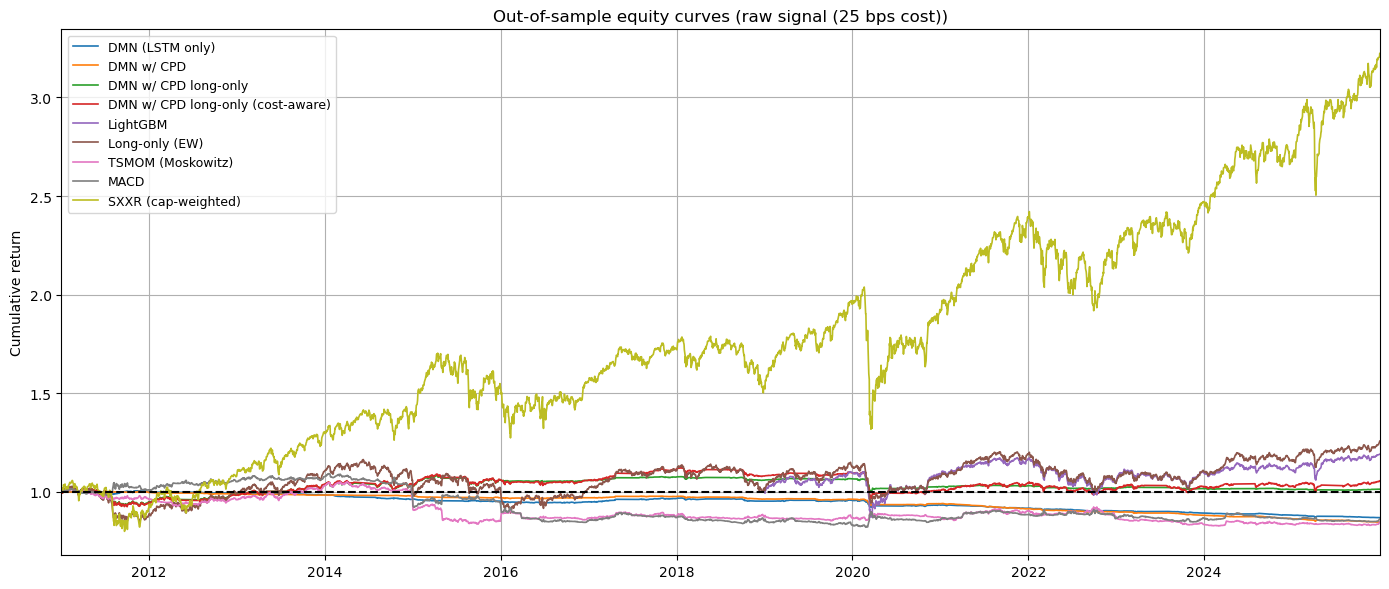

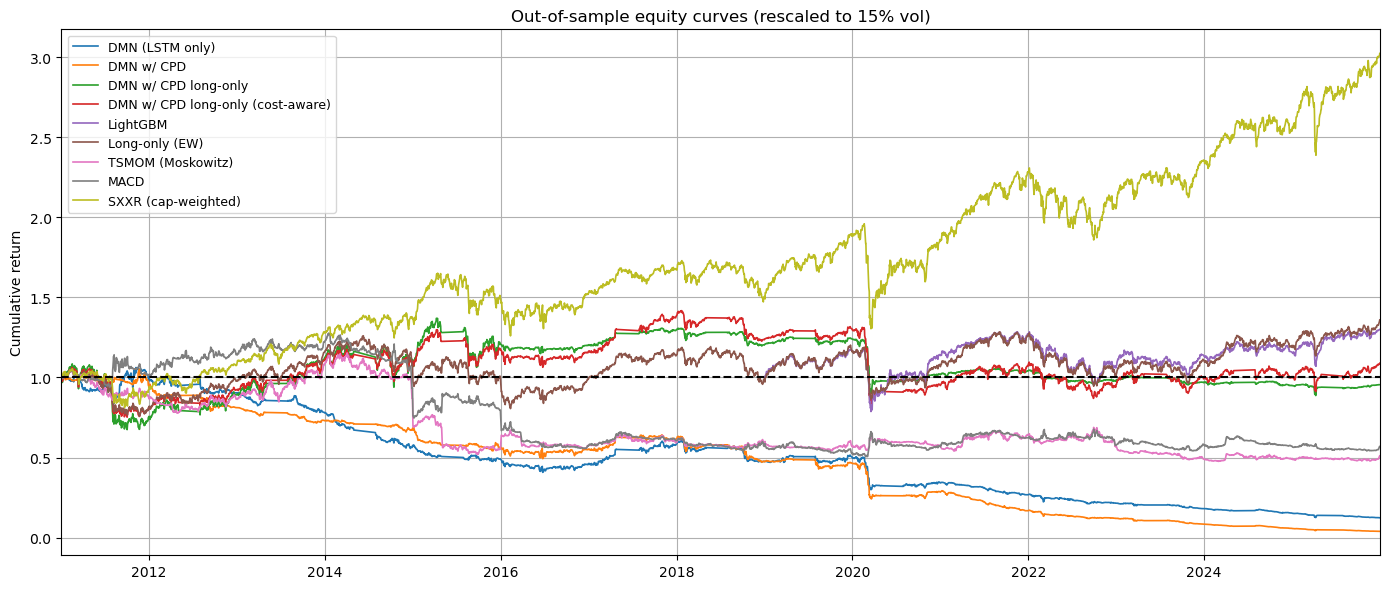

In [11]:
LABELS = {
    "dmn_baseline_net":           "DMN (LSTM only)",
    "dmn_cpd_net":                "DMN w/ CPD",
    "dmn_cpd_longonly_net":       "DMN w/ CPD long-only",
    "dmn_cpd_longonly_tc_net":    "DMN w/ CPD long-only (cost-aware)",
    "lgbm_net":                   "LightGBM",
    "long_only_net":              "Long-only (EW)",
    "moskowitz_net":              "TSMOM (Moskowitz)",
    "macd_net":                   "MACD",
    "sxxr":                       "SXXR (cap-weighted)",
}

# plot_equity_curves imported from src.backtest
plot_equity_curves(portfolios, f"raw signal ({TRANSACTION_COST*1e4:.0f} bps cost)", LABELS).show()
plot_equity_curves(rescaled, f"rescaled to {TARGET_VOL:.0%} vol", LABELS).show()

## Drawdown Analysis

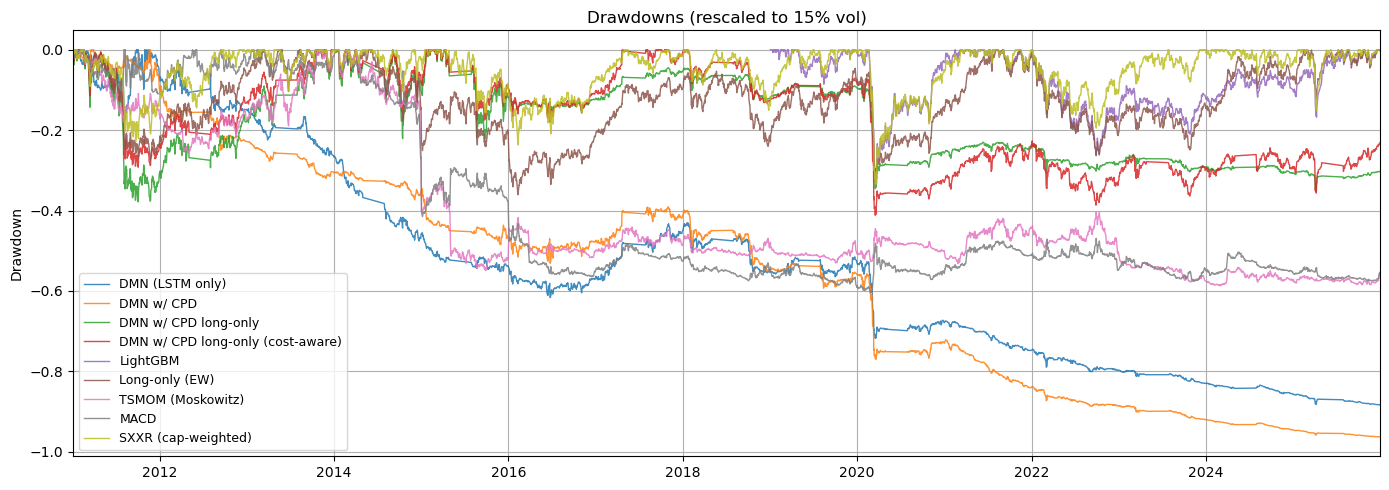

In [12]:
# plot_drawdowns imported from src.backtest
plot_drawdowns(rescaled, TARGET_VOL, LABELS).show()

## Rolling Sharpe ratio
 
Trailing 252-day Sharpe assesses regime-dependence and the CPD module's value-add over time.


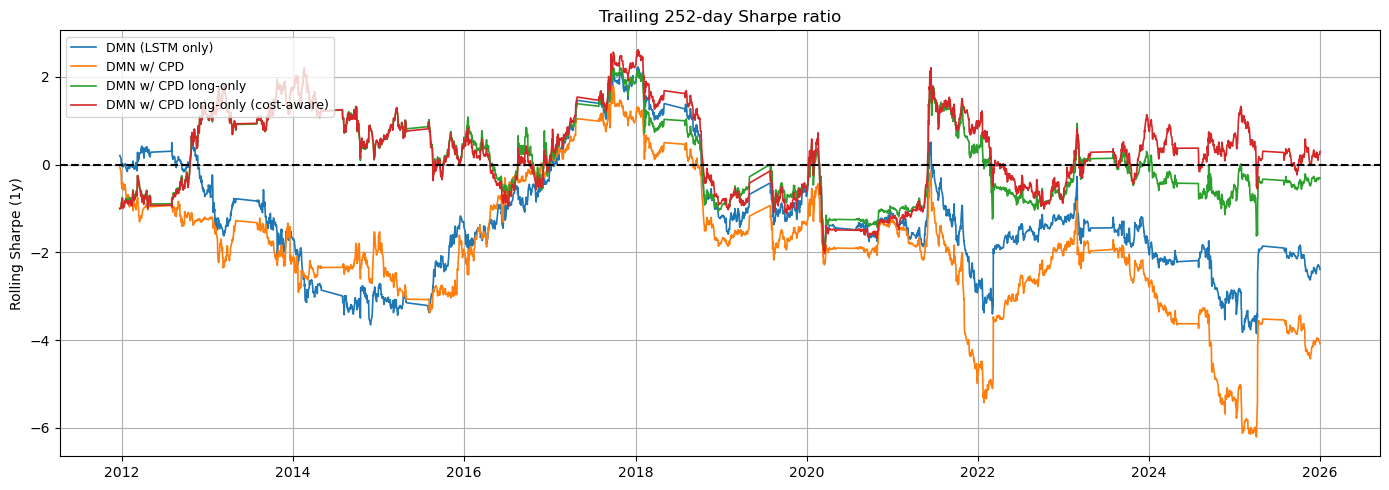

In [13]:
# rolling_sharpe imported from src.metrics

fig, ax = plt.subplots(figsize=(14, 5))
for label in ["dmn_baseline_net", "dmn_cpd_net",
               "dmn_cpd_longonly_net", "dmn_cpd_longonly_tc_net"]:
    if label not in portfolios:
        continue
    rs = rolling_sharpe(portfolios[label])
    ax.plot(rs.index, rs.values, lw=1.2, label=LABELS[label])
ax.axhline(0, color="black", lw=1.5, linestyle="--")
ax.set_title("Trailing 252-day Sharpe ratio")
ax.set_ylabel("Rolling Sharpe (1y)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Sharpe by year
 
Cross-year breakdown for regime-dependence analysis. The paper notes the CPD module is especially valuable in 2015-2020.

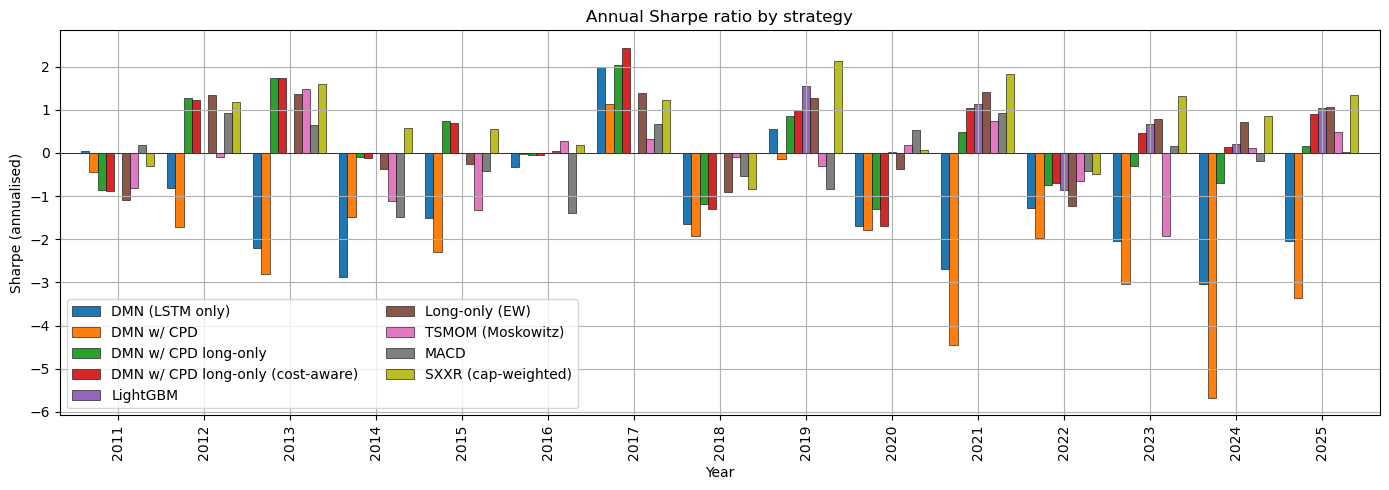


Sharpe by year:
      DMN (LSTM only)  DMN w/ CPD  DMN w/ CPD long-only  DMN w/ CPD long-only (cost-aware)  LightGBM  Long-only (EW)  TSMOM (Moskowitz)  MACD  SXXR (cap-weighted)
date                                                                                                                                                              
2011             0.05       -0.43                 -0.86                              -0.89       NaN           -1.09              -0.80  0.18                -0.29
2012            -0.80       -1.71                  1.27                               1.23       NaN            1.34              -0.09  0.92                 1.18
2013            -2.21       -2.79                  1.75                               1.75       NaN            1.38               1.48  0.65                 1.60
2014            -2.87       -1.50                 -0.10                              -0.12       NaN           -0.38              -1.12 -1.48                 0.58
2015 

In [14]:
# yearly_sharpe imported from src.metrics

# Build the yearly table for strategies we want to compare
yearly_table = pd.DataFrame({
    LABELS[label]: yearly_sharpe(portfolios[label])
    for label in LABELS if label in portfolios
})

fig, ax = plt.subplots(figsize=(14, 5))
yearly_table.plot(kind="bar", ax=ax,width=0.85, edgecolor="black", linewidth=0.4,)
ax.set_title("Annual Sharpe ratio by strategy")
ax.set_ylabel("Sharpe (annualised)"); ax.set_xlabel("Year")
ax.axhline(0, color="black", lw=0.5)
ax.legend(ncol=2, loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nSharpe by year:")
print(yearly_table.round(2).to_string())

## Transaction cost sensitivity (paper Exhibit 8)
 
How does Sharpe degrade as we increase per-transaction cost from 0 bps to 50 bps? The paper notes DMNs deteriorate quickly above ~2 bps without a cost-aware loss; with a cost-aware model (our `dmn_cpd_longonly_tc` variant), we expect more graceful degradation.

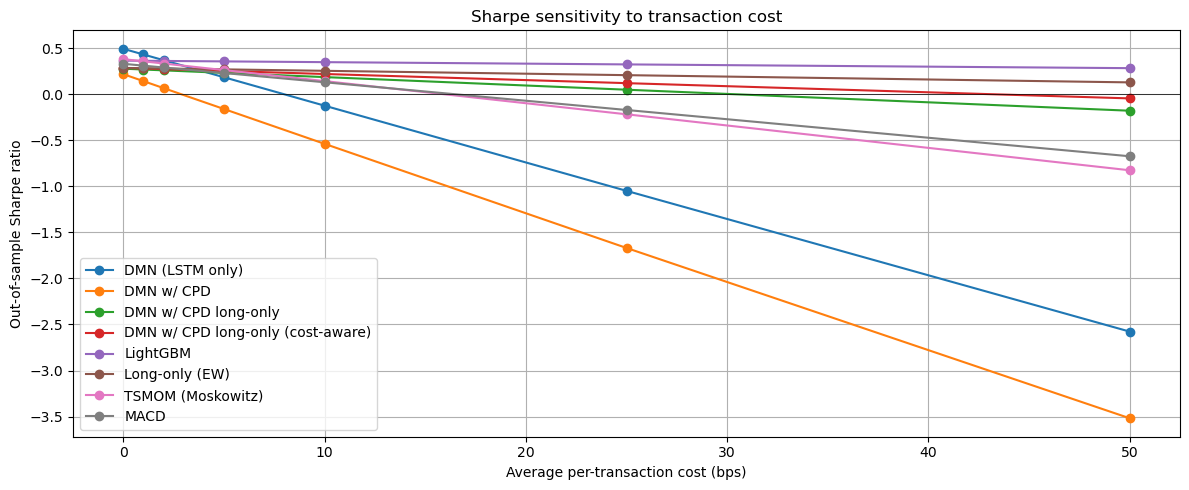


Sharpe at each cost level:
            dmn_baseline  dmn_cpd  dmn_cpd_longonly  dmn_cpd_longonly_tc   lgbm  long_only  moskowitz   macd
Cost (bps)                                                                                                  
0                  0.495    0.219             0.279                0.288  0.366      0.287      0.383  0.332
1                  0.433    0.144             0.270                0.281  0.365      0.284      0.359  0.312
2                  0.371    0.068             0.261                0.274  0.363      0.281      0.335  0.292
5                  0.186   -0.159             0.233                0.254  0.358      0.272      0.264  0.232
10                -0.123   -0.538             0.188                0.221  0.350      0.256      0.144  0.132
25                -1.048   -1.669             0.051                0.122  0.325      0.209     -0.217 -0.170
50                -2.577   -3.518            -0.178               -0.044  0.285      0.130     -0.82

In [15]:
COST_GRID_BPS = [0, 1, 2, 5, 10, 25, 50]
COST_GRID = [c * 1e-4 for c in COST_GRID_BPS]

# sharpe_at_cost imported from src.backtest
cost_sens = {}
for label, df in dmn_predictions.items():
    cost_sens[label] = [sharpe_at_cost(df, c) for c in COST_GRID]

for name in ["long_only", "moskowitz", "macd"]:
    cost_sens[name] = [
        sharpe_at_cost(
            classical, c,
            position_col=f"pos_{name}", vol_col="60d_ewm_vol",
            gross_col=f"strat_{name}_gross",
        )
        for c in COST_GRID
    ]

cost_table = pd.DataFrame(cost_sens, index=COST_GRID_BPS)
cost_table.index.name = "Cost (bps)"

fig, ax = plt.subplots(figsize=(12, 5))
for label in cost_table.columns:
    display_label = LABELS.get(label + "_net", LABELS.get(label, label))
    ax.plot(cost_table.index, cost_table[label], marker="o", lw=1.5,
             label=display_label)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Average per-transaction cost (bps)"); ax.set_ylabel("Out-of-sample Sharpe ratio")
ax.set_title("Sharpe sensitivity to transaction cost")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nSharpe at each cost level:")
print(cost_table.round(3).to_string())

## Limitations

- **Signal faible** : les Sharpe bruts des DMN restent modestes (< 0.5), proches du long-only EW simple. L'IC moyen ≈ 0.005 implique que le modèle prédit correctement la direction environ 50.25% des jours — légèrement au-dessus du hasard.
- **Comparaison LSTM / LightGBM asymétrique** : le LSTM est testé sur 2011–2025 (3 folds × 5 ans), le LightGBM sur 2019–2026 (8 folds annuels). Les Sharpe sont directement comparables uniquement sur la période commune 2019–2025.
- **Sensibilité aux frais** : au-delà de 10 bps, toutes les stratégies long-short DMN affichent un Sharpe net négatif. Seules les versions long-only et LightGBM (grâce à l'EMA + calibration alpha) survivent à 25 bps.
- **Biais de survivance** : l'univers STOXX 600 est fixé à la composition 2025–2026. Les données historiques incluent des actions aujourd'hui présentes dans l'indice mais peut-être absentes ou illiquides avant 2015, introduisant un biais de survivance potentiel.